# 16. Continuous Wavelet Transform (CWT)
**Objective:** Transform raw sEMG windows into 2D Time-Frequency Spectrograms, converting the biomedical signal problem into a high-resolution deep vision problem.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.config import PREPROCESSED_DIR
from src.cwt_features import extract_cwt_spectrograms

plt.style.use('seaborn-v0_8-whitegrid')

### 1. Load Preprocessed Data

In [2]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y']).astype(np.int64)

### 2. Extract CWT Spectrograms

In [3]:
# Extract 16 frequency scales
X_cwt = extract_cwt_spectrograms(X_bal, n_scales=16, n_jobs=-1)

Starting parallel CWT extraction on 18630 windows...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19260530184111085s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09260034561157227s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  76 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 106 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18474292755126953s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    1.6s
[Parallel(n_job

CWT extraction complete. Spectrogram tensor shape: (18630, 16, 20, 10)


### 3. Visualize the 2D Spectrogram
Let's see what a gesture looks like when converted to a Time-Frequency Image.

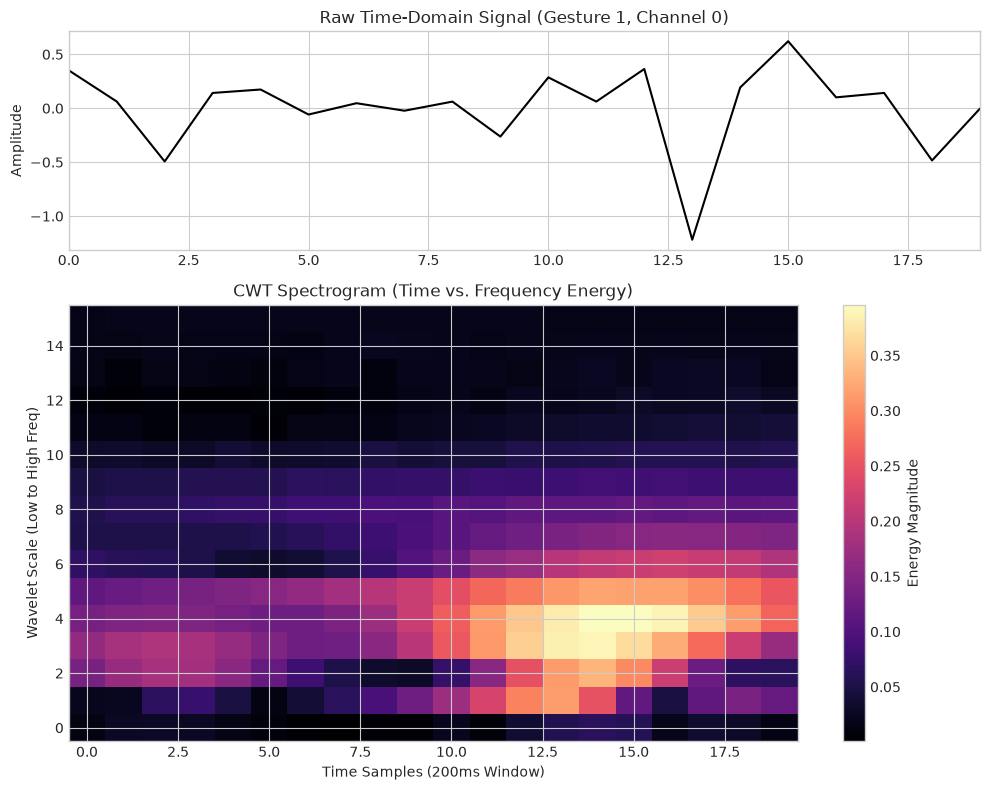

In [4]:
active_idx = np.where(y_bal > 0)[0][15]
channel_idx = 0

raw_signal = X_bal[active_idx, :, channel_idx]
spectrogram = X_cwt[active_idx, :, :, channel_idx]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 2]})

# Top: Raw Time Domain
axes[0].plot(raw_signal, color='black')
axes[0].set_title(f"Raw Time-Domain Signal (Gesture {y_bal[active_idx]}, Channel {channel_idx})")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim([0, 19])

# Bottom: CWT Spectrogram Image
im = axes[1].imshow(spectrogram, aspect='auto', cmap='magma', origin='lower')
axes[1].set_title("CWT Spectrogram (Time vs. Frequency Energy)")
axes[1].set_xlabel("Time Samples (200ms Window)")
axes[1].set_ylabel("Wavelet Scale (Low to High Freq)")
fig.colorbar(im, ax=axes[1], label="Energy Magnitude")

plt.tight_layout()
plt.show()